In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import iradon

In [2]:
freq = 1295e6
c= 299792458
pri = 19.7e-3
cpi = 128

In [3]:
spec_0 = np.load('/share/nas2/pryder/tumbling_git/spectrogram___intelsat_128cpi_1sampoverlap_tukey_128pad_106_strips.npy')
spec_1 = np.load('/share/nas2/pryder/tumbling_git/spectrogram_a_intelsat_128cpi_1sampoverlap_tukey_128pad_106_strips.npy')
spec_2 = np.load('/share/nas2/pryder/tumbling_git/spectrogram_b_intelsat_128cpi_1sampoverlap_tukey_128pad_106_strips.npy')
spec_3 = np.load('/share/nas2/pryder/tumbling_git/spectrogram_c_intelsat_128cpi_1sampoverlap_tukey_128pad_106_strips.npy')
combined_spec = np.hstack((spec_0, spec_1, spec_2, spec_3))
combined_spec.shape

(256, 424)

In [4]:
time = np.arange(combined_spec.shape[1])*pri*cpi
period = 15.1
period_fraction = (time/period)%10
angles = 360 * period_fraction

In [5]:
img = iradon(combined_spec, angles, circle=True, filter_name='hamming')

In [11]:
wv = c / freq
dx = c / (2 * 8e6)                  # Range pixel resolution - c/2bandwidth
dy = wv / (2 * 0.01)   # Cross-range pixel resolution - λ/2beamwidth

N_row = combined_spec.shape[1]
M_col = combined_spec.shape[1]
range_axis = (np.arange(N_row) - (N_row / 2)) * dx
cross_range_axis = (np.arange(M_col) - (M_col / 2)) * dy

In [6]:
plt.imshow(img, origin='lower', aspect='auto', vmin=60000, extent=[range_axis[0], range_axis[-1], cross_range_axis[0], cross_range_axis[-1]])
plt.xlim(-1000, 1000)
plt.ylim(-1000, 1000)
plt.colorbar()
plt.show()

NameError: name 'range_axis' is not defined

In [13]:
np.max(img)

np.float64(73916.57269984504)

### Making this into a function

In [12]:
def make_isar_image(time, period, spec, freq=1295e6, bw=8e6, beamwidth=0.01, vm=-10, filter='ramp', plot=True, verbose=False, lim = None):
    '''
    Inputs:
        time: array of times corresponding to each strip of spectrogram (s)
        period: rotation period (s)
        freq: central frequency (Hz)
        bw: bandwidth (Hz)
        beamwidth: beamwidth (not sure, maybe this is where it's going wrong)
        filter: filter to use for iradon transform
        plot: if True, plot will be made
        verbose: if True, outputs will be printed

    Outputs:
        peak: maximum power in image
        snr: peak to median ratio
        '''
    period_fraction = (time/period)%10
    angles = 360 * period_fraction
    img = iradon(spec, angles, circle=True, filter_name=filter)
    wv = c / freq
    dx = c / (2 * bw)                  # Range pixel resolution - c/2bandwidth
    dy = wv / (2 * beamwidth)   # Cross-range pixel resolution - λ/2beamwidth
    max_velocity = c / (4*pri*freq)
    minn = -max_velocity * period/(2*np.pi)
    maxx = max_velocity * period/(2*np.pi)
    img_dB = 10 * np.log10(np.abs(img)**2 + 1e-12)
    img_dB -= np.max(img_dB)
    if plot==True:
        if lim == None:
            plt.imshow(img_dB, origin='lower', aspect='auto', vmin=vm, extent=[minn, maxx, minn, maxx])
            plt.xlabel('X (m)')
            plt.ylabel('Y (m)')
            # plt.xlim(-1000, 1000)
            # plt.ylim(-1000, 1000)
            plt.colorbar(label='Power (dB)')
            plt.show()
        else:
            plt.imshow(img_dB, origin='lower', aspect='auto', vmin=vm, extent=[minn, maxx, minn, maxx])
            plt.xlim(-lim, lim)
            plt.ylim(-lim, lim)
            plt.xlabel('X (m)')
            plt.ylabel('Y (m)')
            plt.colorbar(label='Power(dB)')
            plt.show()
    peak = np.max(img)
    constrast = np.max(img)- np.min(img)
    noise = 60000 #np.mean(img)
    # print(noise)
    snr = peak/noise
    if verbose ==True:
        print('peak: ', peak)
        print('snr: ', snr)
    return constrast, snr

Trying period:  15
Period updated
Trying period:  15.001
No improvement
Trying period:  15.001999999999999
Period updated
Trying period:  15.002999999999998
Period updated
Trying period:  15.003999999999998
Period updated
Trying period:  15.004999999999997
Period updated
Trying period:  15.005999999999997
No improvement
Trying period:  15.006999999999996
No improvement
Trying period:  15.007999999999996
No improvement
Trying period:  15.008999999999995
No improvement
Trying period:  15.009999999999994
No improvement
Trying period:  15.010999999999994
No improvement
Trying period:  15.011999999999993
No improvement
Trying period:  15.012999999999993
Period updated
Trying period:  15.013999999999992
No improvement
Trying period:  15.014999999999992
No improvement
Trying period:  15.015999999999991
No improvement
Trying period:  15.01699999999999
No improvement
Trying period:  15.01799999999999
No improvement
Trying period:  15.01899999999999
No improvement
Trying period:  15.019999999999

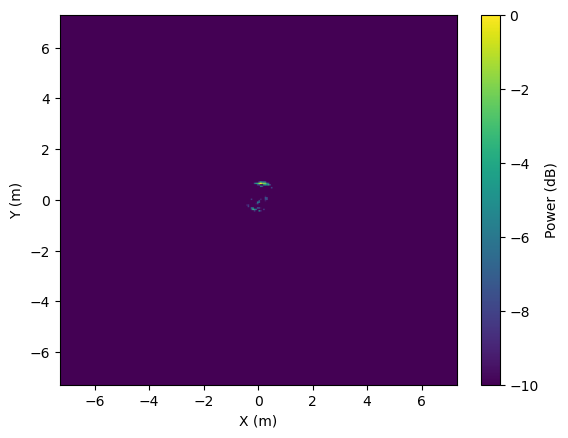

Best period:  15.580999999999678


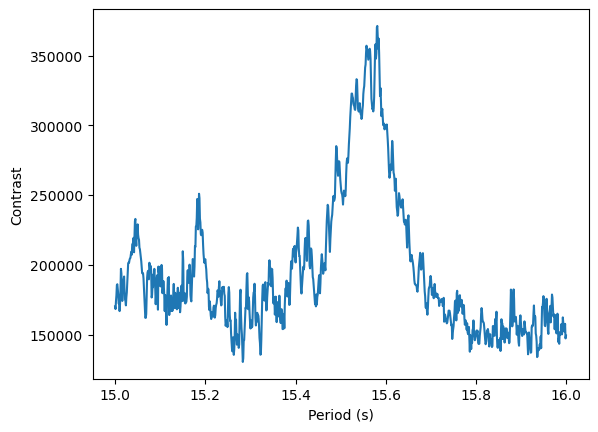

In [25]:
period = 15
best_period = 0
best_peak = 0
period_history = []
peak_history = []
snr_history = []
for i in range(1000):
    p, n = make_isar_image(time, period, combined_spec, plot = False,verbose=False)
    print('Trying period: ', period)
    period_history.append(period)
    peak_history.append(p)
    snr_history.append(n)
    if p>best_peak:
        best_peak = p
        best_period = period
        print('Period updated')
    else:
        print('No improvement')
    period += 0.001

p, n = make_isar_image(time, best_period, combined_spec)
print('Best period: ', best_period)
plt.plot(period_history, peak_history)
plt.xlabel('Period (s)')
plt.ylabel('Contrast')
plt.show()
# plt.plot(period_history, snr_history)
# plt.xlabel('Period (s)')
# plt.ylabel('SNR')
# plt.show()


In [76]:
from scipy.signal import find_peaks
peaks, ppp = find_peaks(snr_history, height=2.28)
print(peaks)
period_history[15]

[ 15 146 301]


2.5000000000000013

In [ ]:
max_velocity = c / (4*pri*freq)
minn = -max_velocity * period/(2*np.pi)
maxx = max_velocity * period/(2*np.pi)

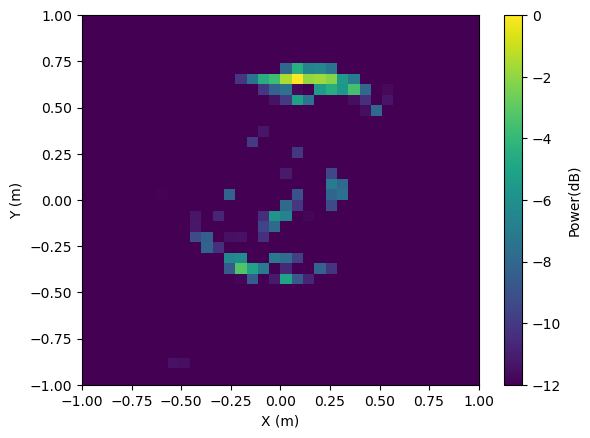

In [29]:
_, _ = make_isar_image(time, best_period, combined_spec, vm=-12, lim=1)


In [71]:
period = best_period #15.5802
time_folded = time % period
phase = time_folded / period
sort_indices = np.argsort(time_folded)
time_folded_sorted = time_folded[sort_indices]
data_sorted = combined_spec[:, sort_indices]
max_velocity = c / (4*pri*freq)

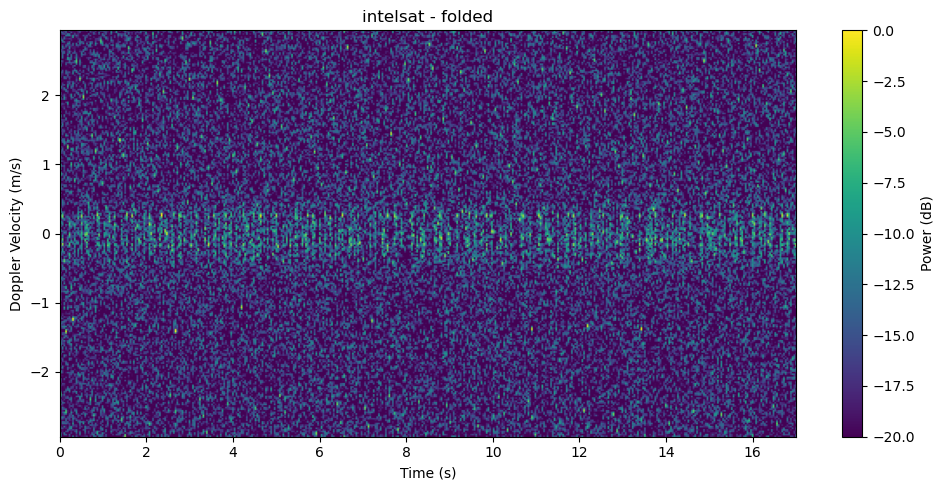

In [72]:
plt.figure(figsize=(10, 5))
# +1e-12 is there to avoid log of 0
plt.imshow(10 * np.log10(data_sorted+1e-12)-np.max(10 * np.log10(data_sorted+1e-12)), aspect='auto', origin='lower', vmin=-20, extent= [0, period, -max_velocity, max_velocity])
plt.title("intelsat - folded")
plt.xlabel("Time (s)")
plt.ylabel("Doppler Velocity (m/s)")
plt.colorbar(label='Power (dB)')
# plt.ylim(-1.5, 1.5)
# plt.vlines((59,84), -max_velocity, max_velocity, 'r')
plt.tight_layout()

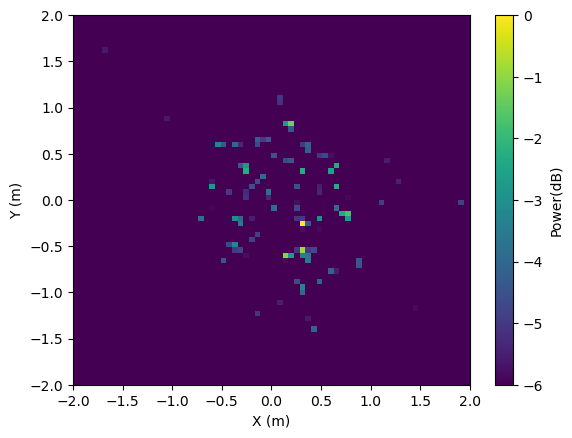

In [66]:
_, _ = make_isar_image(time_folded, period, data_sorted, vm=-6, lim=2)

Trying period:  13
Period updated
Trying period:  13.1
Period updated
Trying period:  13.2
No improvement
Trying period:  13.299999999999999
No improvement
Trying period:  13.399999999999999
No improvement
Trying period:  13.499999999999998
No improvement
Trying period:  13.599999999999998
No improvement
Trying period:  13.699999999999998
Period updated
Trying period:  13.799999999999997
No improvement
Trying period:  13.899999999999997
No improvement
Trying period:  13.999999999999996
No improvement
Trying period:  14.099999999999996
No improvement
Trying period:  14.199999999999996
No improvement
Trying period:  14.299999999999995
No improvement
Trying period:  14.399999999999995
No improvement
Trying period:  14.499999999999995
No improvement
Trying period:  14.599999999999994
No improvement
Trying period:  14.699999999999994
No improvement
Trying period:  14.799999999999994
No improvement
Trying period:  14.899999999999993
No improvement
Trying period:  14.999999999999993
No improv

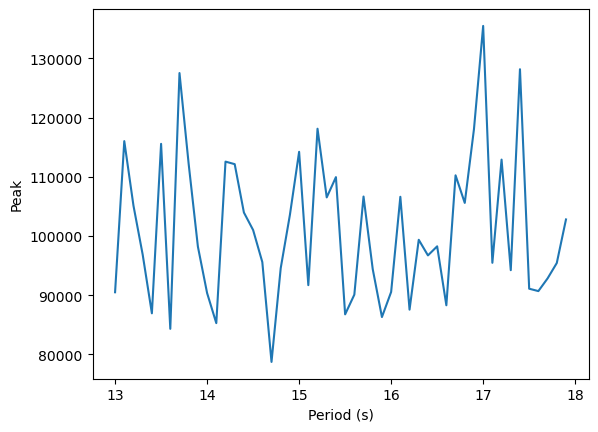

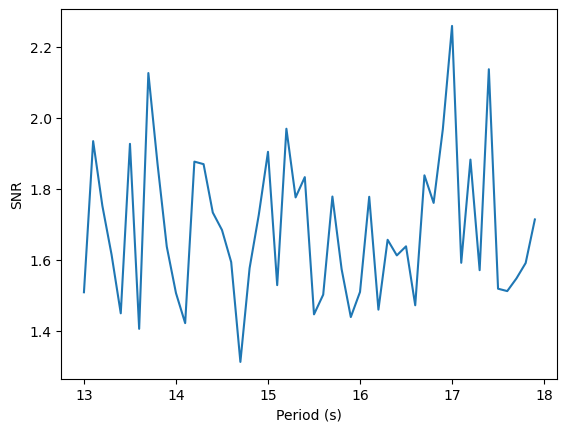

In [69]:
period = 13
best_period = 0
best_peak = 0
period_history = []
peak_history = []
snr_history = []

for i in range(50):
    time_folded = time % period
    phase = time_folded / period
    sort_indices = np.argsort(time_folded)
    time_folded_sorted = time_folded[sort_indices]
    data_sorted = combined_spec[:, sort_indices]
    max_velocity = c / (4*pri*freq)
    p, n = make_isar_image(time_folded, period, data_sorted, plot = False,verbose=False)
    print('Trying period: ', period)
    period_history.append(period)
    peak_history.append(p)
    snr_history.append(n)
    if p>best_peak:
        best_peak = p
        best_period = period
        print('Period updated')
    else:
        print('No improvement')
    period += 0.1

# p, n = make_isar_image(time, best_period, data_sorted)
print('Best period: ', best_period)
plt.plot(period_history, peak_history)
plt.xlabel('Period (s)')
plt.ylabel('Peak')
plt.show()
plt.plot(period_history, snr_history)
plt.xlabel('Period (s)')
plt.ylabel('SNR')
plt.show()


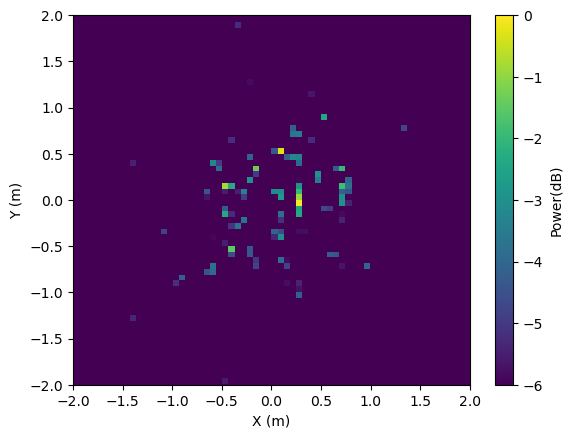

In [70]:
_, _ = make_isar_image(time_folded, best_period, data_sorted, vm=-6, lim=2)